In [2]:
import matplotlib.pyplot as plt
import cv2 as cv
from lcLevy.Image import Img
from skimage.measure import ransac, LineModelND
import numpy as np

patch_size = 50
overlap = 25

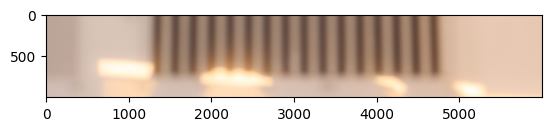

In [57]:
# Traverse over the pixels in the image in chunks
# Analyzing them two at a time just for the sake of this, but I think there
# are probably better solutions we can come up with eventually
# Especially with the need for interpolation

# Maybe make an array as like a map of what all the values are comparing the A_hat between all lateral patches
# Then somehow mesh this, if it's working decently



# Reading in the image
image = cv.imread("EOS_R100_JPG/jpg0006.jpg")
image = image[:,:,::-1]
# image = image[1500:2000,2000:2500]
image = image[3000:,:]
# print(len(image))
# print(image[5999, 0])
plt.imshow(image)

In [50]:
# Helper Functions

def lobf(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    # I'm guessing that the total range is 0-255, but don't really have proof of that
    fit, inliers= ransac(pixels, LineModelND, 200, 2, max_trials = 1000) 
    return (fit, inliers)

def polyfit(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    polyfit_x = np.polyfit(pixels[:][:,2], pixels[:][:,0], 1)
    polyfit_y = np.polyfit(pixels[:][:,2], pixels[:][:,1], 1)
    return[polyfit_x, polyfit_y]

def display_lobf(lobf):
    """TO IMPLEMENT"""
    return None

def normalize(vec):
    l = np.sqrt(vec[0]**2 + vec[1]**2+vec[2]**2)
    return [vec[0]/l, vec[1]/l, vec[2]/l]

def airlight_direction(lobf_one, lobf_two):
    # z1 = [50]
    # z2 = [100]
    z1 = 50
    z2 = 100

    # points on plane 1
    # pt1 = [lobf_one.predict_x(z1)[0], lobf_one.predict_y(z1)[0], z1[0]]
    # pt2 = [lobf_one.predict_x(z2)[0], lobf_one.predict_y(z2)[0], z2[0]]
    pt1 = [z1*lobf_one[0][0] + lobf_one[0][1], z1*lobf_one[1][0] + lobf_one[1][1], z1]
    pt2 = [z2*lobf_one[0][0] + lobf_one[0][1], z2*lobf_one[1][0] + lobf_one[1][1], z1]
    norm_one = np.cross(pt1, pt2)
    # points on plane 2
    pt3 = [z1*lobf_two[0][0] + lobf_two[0][1], z1*lobf_two[1][0] + lobf_two[1][1], z2]
    pt4 = [z2*lobf_two[0][0] + lobf_two[0][1], z2*lobf_two[1][0] + lobf_two[1][1], z2]
    # pt3 = [lobf_two.predict_x(z1)[0], lobf_two.predict_y(z1)[0], z1[0]]
    # pt4 = [lobf_two.predict_x(z2)[0], lobf_two.predict_y(z2)[0], z2[0]]
    norm_two = np.cross(pt3, pt4)

    # This assumes, as I believe we can in this problem that the planes intersect at the origin
    intersect = np.cross(norm_one, norm_two)
    return normalize(intersect)

def dist_from_origin(lobf, z):
    return np.sqrt((z*lobf[0][0] + lobf[0][1])**2 + (z*lobf[1][0] + lobf[1][1])**2 + z**2)
    # return np.sqrt(lobf.predict_x([z])**2 + lobf.predict_y([z])**2 + z**2)

def find_closest_to_origin(lobf):
    # Start at where z = 0, search until we find a value that is closest to the origin
    z = 255
    curr_dist = dist_from_origin(lobf, z)
    new_dist = dist_from_origin(lobf, 250)
    while new_dist<curr_dist:
        z -=5
        curr_dist = new_dist
        new_dist = dist_from_origin(lobf, z)
    
    return curr_dist

def find_direction_multiplier(lobf, A_dir):
    test_zs = range(-100,100,10)
    s = -255
    def avg_dist(s):
        xs = np.mean([np.abs((lobf[0][0]*z + lobf[0][1]) - s*A_dir[0]) for z in test_zs])
        ys = np.mean([np.abs((lobf[1][0]*z + lobf[1][1]) - s*A_dir[1]) for z in test_zs])
        zs = np.mean([np.abs(z - s*A_dir[2]) for z in test_zs])
        return (xs+ys+zs)/3
        
    curr_dist = avg_dist(s)
    new_dist = avg_dist(s+1)
    while new_dist<curr_dist:
        s+=3
        curr_dist = new_dist
        new_dist = avg_dist(s)

    return s
   
  


def airlight_mag(lobf, A):
    # # return find_closest_to_origin(lobf)[0]
    # return find_closest_to_origin(lobf)
    return find_direction_multiplier(lobf, A)

def apply_shift(patch, dir, mag):
    red_frac = (-1)* dir[0]**2  if dir[0]<0 else dir[0]**2
    green_frac = dir[1]**2 *(-1) if dir[1]<0 else dir[1]**2
    blue_frac = dir[2]**2 * (-1) if dir[2]<0 else dir[2]**2

    patch = patch.copy()

    for i in range(len(patch)):
        for j in range(len(patch[0])):
            patch[i][j][0]-= red_frac*mag
            patch[i][j][1]-= green_frac*mag
            patch[i][j][2] -= blue_frac*mag

    return patch

def get_brightness(pixel):
    return (int(pixel[0]) + int(pixel[1]) + int(pixel[2]))/3

def avg_brightness(patch):
    patch = patch.reshape(patch_size**2, 3)
    patch = [get_brightness(pix) for pix in patch]
    return sum(patch) / len(patch)




In [ ]:
# Functions for "vetting" patches

# False if there isn't enough pixel variation
def highly_variable(patch):
    patch = patch.reshape(patch_size**2, 3)
    patch = [get_brightness(pix) for pix in patch]
    # Reasonable threshold seems like 35-40??
    return np.max(patch)-np.min(patch)>20

# False if there's a significant edge in the patch - an attempt to rule out patches with different distance objects
# can implement this later if need be - may need to train something,
# i don't think it will be too important for this use case, though
# def too_edgy(patch):
#     return cv.Canny(patch, 199, 200)

# False if the pixel is too white (too close to airlight color already)
def too_white(patch):
    patch = patch.reshape(patch_size**2, 3)
    size = len(patch)
    thresh = 100
    return np.max([np.abs(int(pix[0])-int(pix[1])) for pix in patch]) <thresh and np.max([np.abs(int(pix[0])-int(pix[2])) for pix in patch]) <thresh and avg_brightness(patch)>125 


# def exclude_outlying_mag()
        


def display_edges(edges):
    cv.imshow("Canny Edge Detection", edges)



In [58]:

# Change this into feeding the airlight params into a big array so the values can be generalized
mags = np.zeros((len(image)//(patch_size-overlap), len(image[0])//(patch_size-overlap)), dtype = type([0.0]))
airlight_dir = []# np.zeros((len(image)//(patch_size-overlap), len(image[0])//(patch_size-overlap)), dtype = type([0.0]))
# array = []

# Actually iterating through the image
for i in range(0, (len(image)//(patch_size-overlap))-1):
    for j in range(0, (len(image[0])//(patch_size-overlap))-2, 2):
        row = i*(patch_size-overlap)
        col = j*(patch_size-overlap)
     
        patch_one = image[row:row+patch_size, col:col+patch_size]
        patch_two = image[row:row+patch_size, col+overlap: col+patch_size+overlap]

        if not too_white(patch_one) and not too_white(patch_two) and highly_variable(patch_one) and highly_variable(patch_two):
            # l1 = lobf(patch_one)[0]
            # l2 = lobf(patch_two)[0]
            l1 = polyfit(patch_one)
            l2 = polyfit(patch_two)
            # print(l1)

            A_hat = airlight_direction(l1, l2)
            # print(A_hat)
            a_1 = airlight_mag(l1, A_hat)
            a_2 = airlight_mag(l2, A_hat)
        
        # print(A_hat)
        # print(a_1, a_2, row, col)
            # image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, A_hat, a_1)
            # image[row:row+patch_size,col+patch_size:col+patch_size*2] = apply_shift(patch_two, A_hat, a_2)
            mags[i][j] = a_1
            mags[i][j+1] = a_2
            airlight_dir.append(A_hat)
            # airlight_dir[i][j+1]= A_hat

    
# plt.imshow(image)
# print(array)




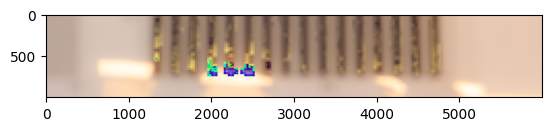

In [59]:
# Applying the changes to the base image
# airlight_dir = airlight_dir.reshape(len(airlight_dir)*len(airlight_dir[0]))
# print(airlight_dir.shape)
A_hat = [np.mean([np.abs(dir[0]) for dir in airlight_dir]), np.mean([np.abs(dir[1]) for dir in airlight_dir]), np.mean([np.abs(dir[2]) for dir in airlight_dir])]

for i in range(len(mags)):
    for j in range(len(mags[0])):
        if mags[i][j] != 0:
            row = i*(patch_size-overlap)
            col = j*(patch_size-overlap)

            patch_one = image[row:row+patch_size, col:col+patch_size]
            # print(mags[i][j])
            image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, A_hat, mags[i][j])

plt.imshow(image)
# print(A_hat)